# Neptune and Pluto
## Setting up a 3-body simulation
This next simulation is a "three-body" simulation - namely a central star and two orbiting planets.  We will use the outer planets Neptune and Pluto (Pluto is technically classed as a "dwarf" planet, but this nomenclature will not effect the simulation!).  Now the simulator needs to calculate the gravitational forces between the Sun and each planets as well as the gravitational forces between two planets themselves. 

Here, we add planets to the simulation by specifying the elements of the planet's orbit.  To do this we need to specify the semi-major axis ($a$), the eccentricity ($e$) and the true anomoly($f$).

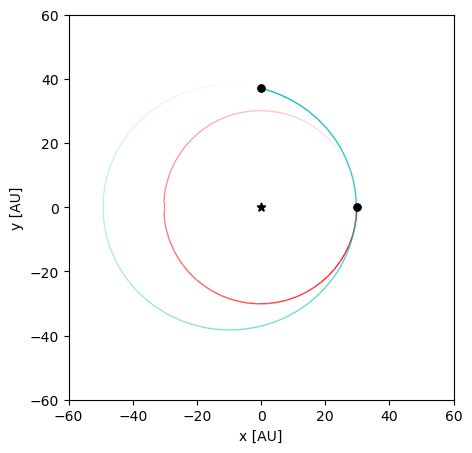

In [1]:
!pip install rebound
import rebound
import numpy as np
import matplotlib.pyplot as plt
import time

#%matplotlib notebook

sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'kg')
sim.t = 0.0

# Define star and planets, add them to the simulation
msun = 1.989e30
sim.add(m=msun, x=0, y=0, z=0, vx=0, vy=0 ,vz=0)

m_Neptune = 1e26
a_Neptune = 30.11
e_Neptune = 0.009
f_Neptune = 0.0

m_Pluto = 1.3e22 * 1000
a_Pluto = 39.482
e_Pluto = 0.2488
f_Pluto = 90

sim.add(m=m_Neptune,a=a_Neptune, e=e_Neptune, f=np.deg2rad(f_Neptune))
sim.add(m=m_Pluto,a=a_Pluto, e=e_Pluto, f=np.deg2rad(f_Pluto))

sim.move_to_com()
op = rebound.OrbitPlot(sim, xlim=(-60.0,60.0), ylim=(-60.0,60.0), unitlabel='[AU]', color=True) # Visualise them

We can make an array of timesteps, so that we can run the simulation over a series of times and plot the output. We keep track of the semi-major axis and eccentricity for each planet. In this example we have 1000 time steps between 0 and 1 million years.  Since 1 million years is quite a long simulation, a timer has been added to check how long the simulation takes (the compute time).

Simulation completed in  2.627053856 seconds


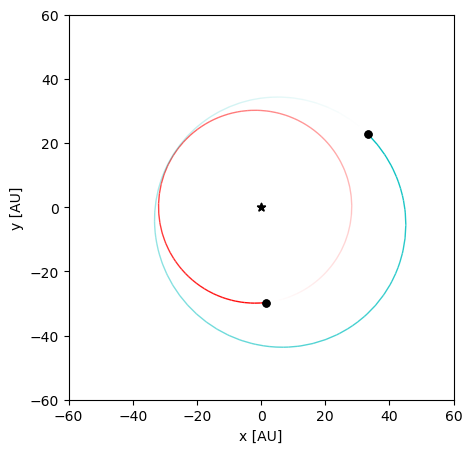

In [2]:
times = np.linspace(0, 1e6, 1000)

#Making the empty arrays in preparation for the simulation output
a_Neptune_time = np.array([])
e_Neptune_time = np.array([])
a_Pluto_time = np.array([])
e_Pluto_time = np.array([])

start_time = time.process_time() # Starting the compute timer

#Looping over the arry of times, and outputing the planet orbits at each timestep.
for t in times:
    sim.integrate(t)
    a_Neptune_time = np.append(a_Neptune_time, sim.particles[1].a )
    e_Neptune_time = np.append(e_Neptune_time, sim.particles[1].e )
    a_Pluto_time = np.append(a_Pluto_time, sim.particles[2].a )
    e_Pluto_time = np.append(e_Pluto_time, sim.particles[2].e )

print("Simulation completed in ",time.process_time() - start_time, "seconds") #Outputing the compute time.
op = rebound.OrbitPlot(sim, xlim=(-60.0,60.0), ylim=(-60.0,60.0), unitlabel='[AU]', color=True)

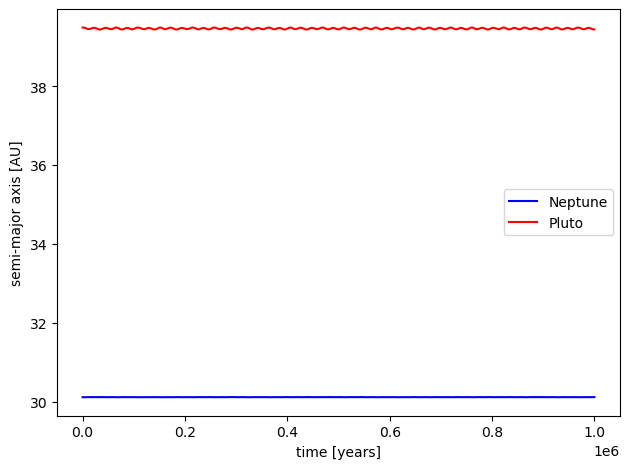

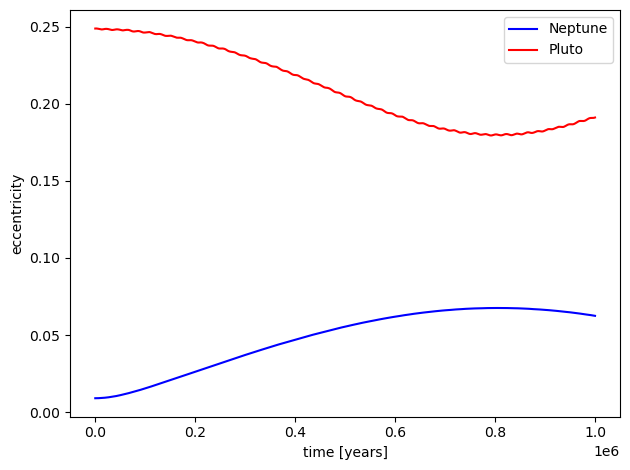

In [3]:
fig, ax = plt.subplots()
ax.plot(times, a_Neptune_time, color='blue', label='Neptune')
ax.plot(times, a_Pluto_time, color='red', label='Pluto')
ax.set_xlabel('time [years]')
ax.set_ylabel('semi-major axis [AU]')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots()
ax.plot(times, e_Neptune_time, color='blue', label='Neptune')
ax.plot(times, e_Pluto_time, color='red', label='Pluto')
ax.set_xlabel('time [years]')
ax.set_ylabel('eccentricity')
ax.legend()
fig.tight_layout()

The plots reveal that while Neptune's orbit remain stable, the orbit of Pluto is rather chaotic, with the eccentricity and semi-major axis undergoing large and non-periodic variations.

# HR 8799 - A real system of four giant exoplanets
Now we are going to model a real exoplanet system - HR 8799.

HR 8799 is a nearby star that is very young - it is 39 parcsec from Earth and is approximately 30 Myr old.  Since stars and planets form at the same time in a given system, the planets in this system are also very young, and thus still shine brightly from their heat of formation.  Because of this they can be directly imaged.  Four exoplanets have been imaged around the star HR 8799. The figure below shows a 1 hour image from the Keck II telescope taken in L band (3.5 microns).  Image from Marios et al., 2010, Nature, 468, 1080.  Note that the light from the central star has been obscured by various optical methods in order to better show the four planets.  The green "star" symbol shows the location of the central star, and the four planets (b,c,d,e) are labeled.

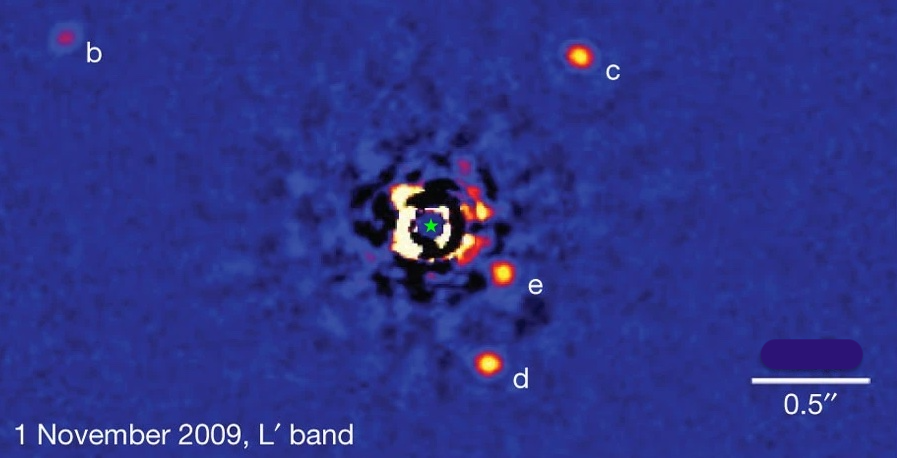

##  Initial planet positions
To set up our `rebound` simulation we will need to first determine the starting positions of the four planets. We should assume circular orbits to begin with ($e=0$). We can work out the initial true anomoly ($f$) of each of the planets by measuring the angles of each of the planets relative to the central star. To work out the semi-major axis ($a$) for each of the planets we will need to make measurements of the image and use the scale bar on the image (which shows 0.5 arc-seconds).  This will give us separations in arc-seconds. Then need to convert arc-seconds to astronomical units (AU). To do this we need to use the distance to the star (39 parsec), and the distance formula

$\alpha=a/d$,

where $\alpha$ is the angular separation in arc-seconds, $d$ is the distance to the star in parsecs, and $a$ is the planet star separation (i.e. the semi-major axis).

## Star and Planet Masses
From the luminosity and spectral features of the central star, we know HR 8799 has a mass of 1.5 solar masses.  The masses of the four planets are trickier to determine, but we can estimate them using age-luminosity models of giant planets.  Giant planets cool as they get older, so their luminosity will decrease with time.  However if we know the age and luminosity, we can estimate their mass.  The table below shows the luminosities of each of the four planets in solar luminosties.

|Planet Name|Luminosity [log\,(L/L$_{\odot}$)]|
|-|-|
|HR 8799 b|-5.5|
|HR 8799 c|-5.2|
|HR 8799 d|-4.9|
|HR 8799 e|-4.7|

We need to estimate the masses for each of these planets using the set of models plotted below.  Each line in the plot is a "cooling track" for a different mass planet.  It shows the luminosity of the planet as a function of age.  The masses of each line are labelled on the right hand side in units of solar masses.  Remember the age of the star is 30Myr, and we can assume the planets are the same age.  Work out the mass for each of the planets, and then convert it to units of kilograms.

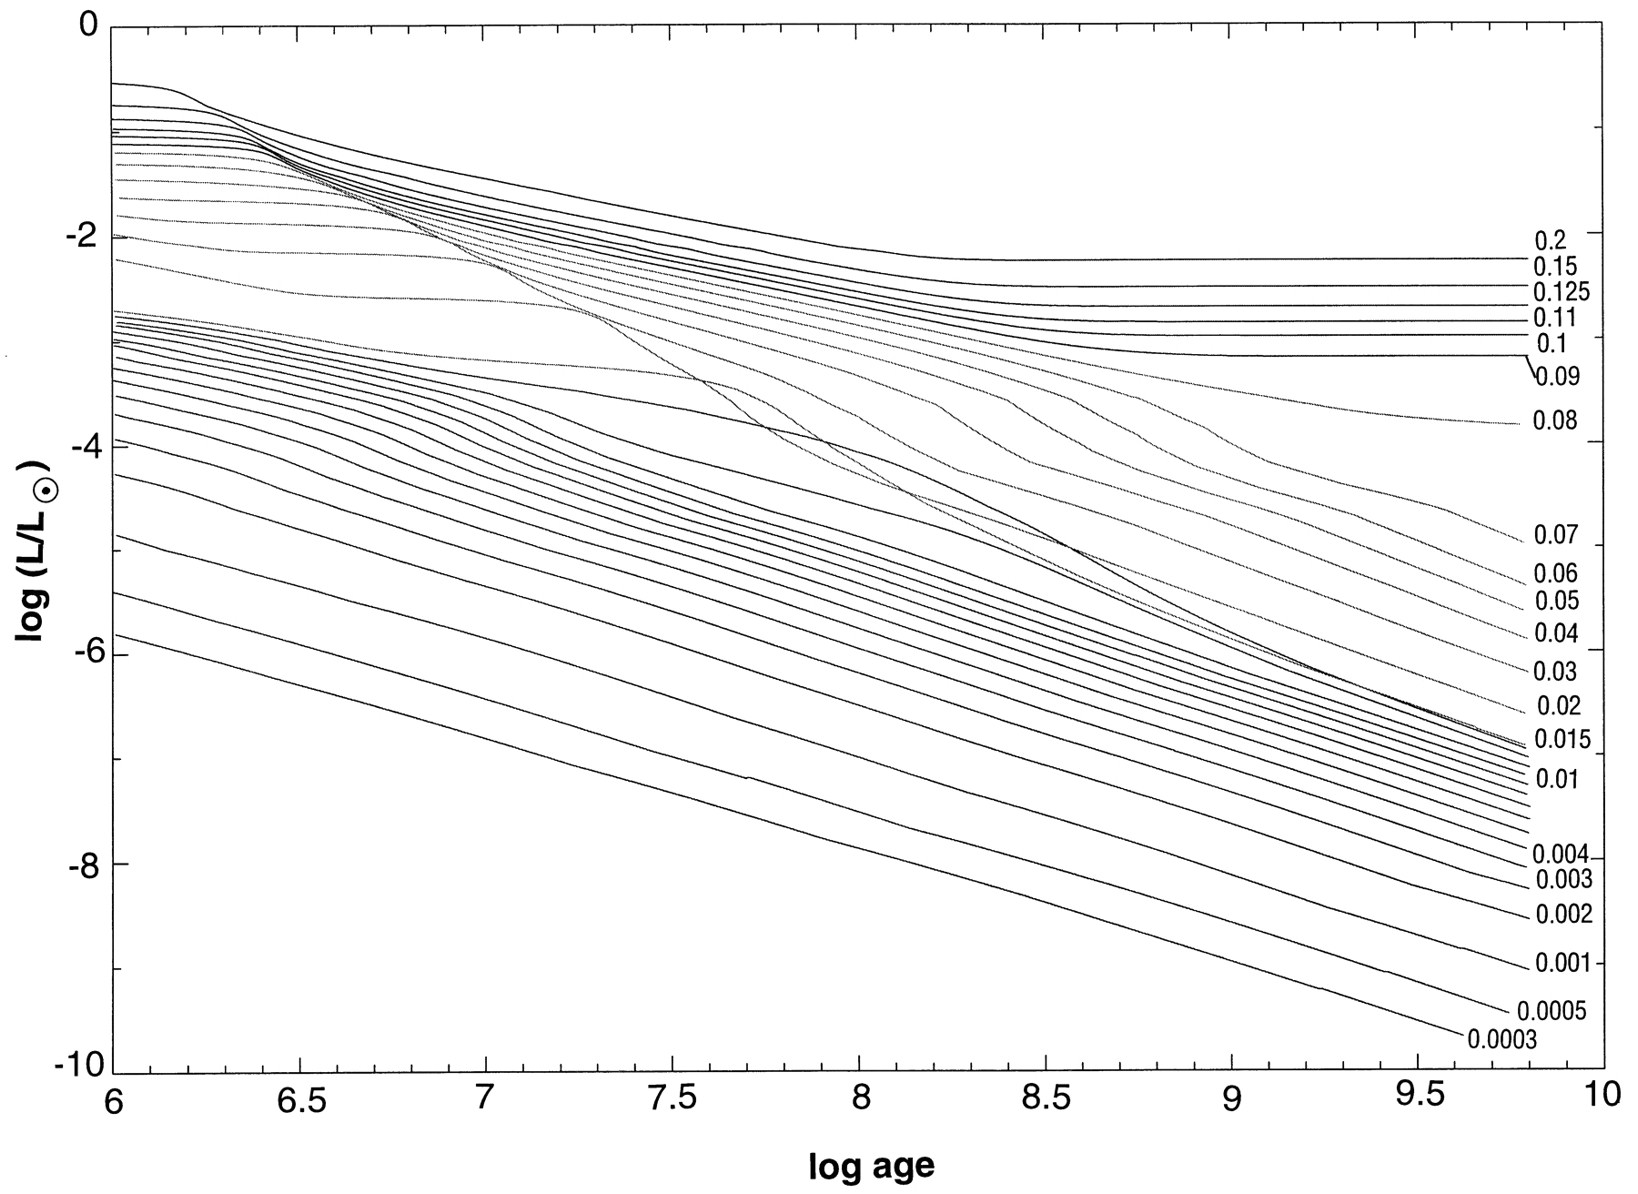

Initializing code...
Displaying initial planetary states...


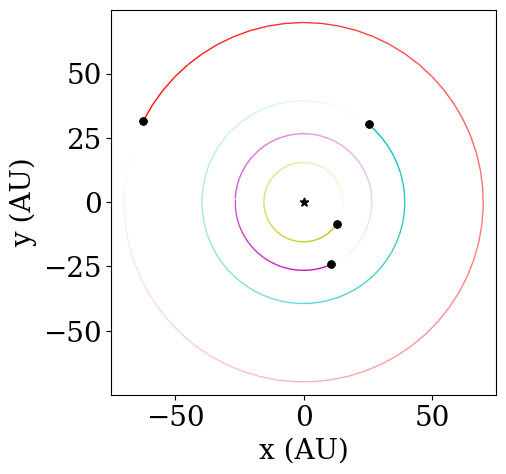

Integrating planetary motion over the course of 4000000.0 years with a timestep of 200 years... This may take a moment.
Done


In [4]:
print("Initializing code...")
# Initialize
!pip install rebound -q
!pip install ffmpeg-python -q
from IPython.display import Audio
import rebound
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Video
import matplotlib.animation as animation
import matplotlib as mpl
%matplotlib inline
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 20,
    "font.size": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# Simulation setup
sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'Msun')
sim.integrator = "ias15"

# Define a function that sets up the planets and their corresponding data
def planetSetup():
    star_m = 1.5 
    d = 39  # distance in parsecs

    #Vary these two parameters to find stable cases
    s1 = 0.55
    s2 = 1.1
    
    planets = [
        {"m": 0.003*s1, "arc": 1.63*s2, "f": 153},
        {"m": 0.004*s1, "arc": 0.92*s2, "f": 50},
        {"m": 0.006*s1, "arc": 0.62*s2, "f": -66},
        {"m": 0.009*s1, "arc": 0.36*s2, "f": -33},
    ]
    
    sim.add(m=star_m)

    for p in planets:
        sim.add(m=p["m"], a=p["arc"] * d, e=0, f=np.deg2rad(p["f"]))

# Call the setup function
planetSetup()
sim.move_to_com()

# Show the initial state of the planets
print("Displaying initial planetary states...")
op = rebound.OrbitPlot(sim, xlim=(-74.9, 74.9), ylim=(-74.9, 74.9), unitlabel='(AU)', color=True)
plt.show()

# --- Data Generation for Plots and Animation ---
duration = 4e6
frames = duration/200
timestep = int(duration/frames)

print("Integrating planetary motion over the course of", duration, "years with a timestep of", timestep, "years... This may take a moment.")

times = np.linspace(0, duration, int(frames))
N_particles = sim.N
N_times = len(times)

# Prepare arrays for all data
x_coords = np.zeros((N_particles, N_times))
y_coords = np.zeros((N_particles, N_times))
a_values = np.zeros((N_particles, N_times))
e_values = np.zeros((N_particles, N_times))

# Main integration loop
for i, t in enumerate(times):
    sim.integrate(t)
    for j, p in enumerate(sim.particles):
        x_coords[j, i] = p.x
        y_coords[j, i] = p.y
        if j > 0:
            a_values[j, i] = p.a
            e_values[j, i] = p.e
print("Done")

Displaying final planetary states...


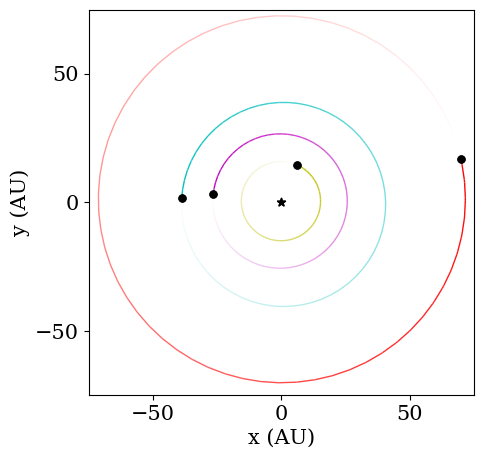

Displaying graphs of eccentricity and semi-major axis as functions of time...


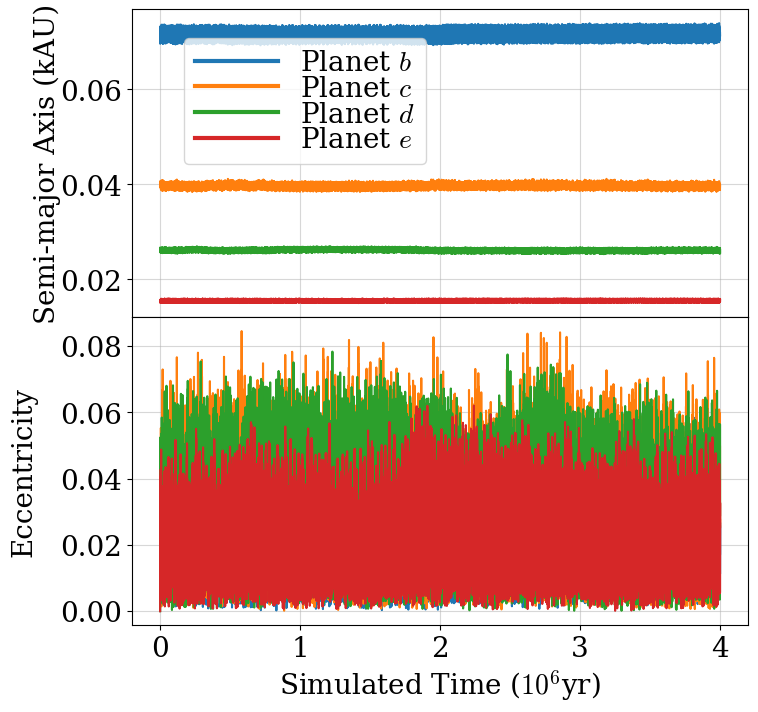

Done.


In [5]:
#Showing final states of planets
print("Displaying final planetary states...")
op = rebound.OrbitPlot(sim, xlim=(-74.9, 74.9), ylim=(-74.9, 74.9), unitlabel='(AU)', color=True)
ax = plt.gca()
ax.set_xlabel("x (AU)", fontsize=15)
ax.set_ylabel("y (AU)", fontsize=15)
ax.set_yticks(np.array([-50, 0 , 50]))
ax.set_xticks(np.array([-50, 0 , 50]))
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("Orbit Plot.pdf", bbox_inches="tight")
plt.show()

scaled_times = times/1e6

# Create Plots for Orbital Elements
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8),sharex=True)
fig.subplots_adjust(hspace=0)
for ax in (ax1, ax2): 
    ax.set_box_aspect(0.5)  # height / width = 1/2
    ax.tick_params(axis='both', labelsize=20)

alphabet = ["a","b","c","d","e"]
# Semi-major Axis vs. Time
for i in range(1, N_particles): # Start from 1 to skip the star
    ax1.plot(scaled_times, a_values[i, :]/1e3, label=rf'Planet ${alphabet[i]}$')
ax1.set_ylabel(rf"Semi-major Axis (kAU)", fontsize=20, labelpad = 0)
leg = ax1.legend(
    loc="upper right",
    bbox_to_anchor=(0.5, 0.95),
    fontsize=20,
    handlelength = 3,
    labelspacing = -0.05
)
for line in leg.get_lines():
    line.set_linewidth(3)

ax1.grid(True, alpha=0.5)

# Eccentricity vs. Time
for i in range(1, N_particles): # Start from 1 to skip the star
    ax2.plot(scaled_times, e_values[i, :])
ax2.set_ylabel("Eccentricity", fontsize=20, labelpad = 17)
ax2.set_xlabel(rf"Simulated Time ($10^{6}$yr)", fontsize=20)
ax2.ticklabel_format(style='plain', axis='x')
ax2.grid(True, alpha=0.5)

print("Displaying graphs of eccentricity and semi-major axis as functions of time...")
plt.savefig("Orbital Elements 2.pdf", bbox_inches="tight")
plt.show()






















# Animation setup 
def animSetup():
    fig, ax = plt.subplots(figsize=(8, 8))
    
    max_range = np.max(np.abs(x_coords)) * 1.1
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_aspect('equal')
    ax.set_xlabel("x-position [AU]")
    ax.set_ylabel("y-position [AU]")
    ax.set_title("Planetary System Animation")
    
    trail_length = 75
    colours = plt.cm.viridis(np.linspace(0, 1, N_particles))
    particle_trails = [ax.plot([], [], color=colours[i], alpha=0.5, lw=1.5)[0] for i in range(N_particles)]
    particle_dots = [ax.plot(x_coords[i, 0], y_coords[i, 0], 'o', color=colours[i])[0] for i in range(N_particles)]
    particle_dots[0].set_markersize(10)
    time_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, verticalalignment='top', fontsize=12)

#animSetup()
# Define the animation function
def animate(i):
    for j in range(N_particles):
        particle_dots[j].set_data([x_coords[j, i]], [y_coords[j, i]])
        start_index = max(0, i - trail_length)
        trail_x = x_coords[j, start_index:i]
        trail_y = y_coords[j, start_index:i]
        particle_trails[j].set_data(trail_x, trail_y)
    
    time_text.set_text(f'Time = {times[i]:.0f} years')
    return particle_dots + particle_trails + [time_text]
# Run the animation
def run():
    ani = animation.FuncAnimation(
        fig, 
        animate, 
        frames=N_times,
        interval=30, 
        blit=True
    )
#run()
# Animation saving
saveAnim = False #Change this if you want to update the mp4
if saveAnim == True:
    print("Saving animation to MP4... This may take a moment.")
    ani.save('planetary_animation.mp4', writer='ffmpeg', dpi=150)
    print("Complete.")
plt.close(fig) 
# Display most recently the saved MP4 file in the notebook
#print("Displaying most recently saved animation in Jupyter notebook...")
#Video("planetary_animation.mp4")
# Notification
def notif():
    sample_rate = 44100  # Hertz
    duration = 0.5       # Seconds
    frequency = 500.0    # Hertz
    t = np.linspace(0., duration, int(sample_rate * duration), endpoint=False)
    waveform = np.sin(2. * np.pi * frequency * t)
    sd.play(waveform, sample_rate)
    sd.wait()
#notif()
print("Done.")